# Probability Bootcamp Notebook

### This notebook contains my code practice and notes for learning [Probability Bootcamp](https://www.youtube.com/playlist?list=PLMrJAkhIeNNR3sNYvfgiKgcStwuPSts9V).
21 Mar - 24 Mar, 2026

### Content
| Section | Lecture | Title |
| :------ | :----- | :---- |
| **I. Intro to Probability** | 1 | Probability and Statistics: Overview |
| | 2 | Gentle Introduction to Probability: Counting Coin Flips and Dice |
| | 3 | Counting Probabilities with Combinatorics and the Factorial |
| | 4 | Set Theory in Probability: Sample Spaces and Events |
| | 5 | The Birthday Problem in Probability: P(A) = 1 - P(not A) |
| **II. Random Variable X & Functions / Distributions** | 6 | Quality Control, Non-Destructive Inspection, and the Multinomial Distribution |
| | 7 | The Binomial Distribution and the Multinomial Distribution |
| | 8 | Conditional Probabilities |
| | 9 | The Law of Total Probability |
| | 10 | Bayes' Theorem (with Example!) |
| | 11 | Bayes' Theorem Example: Drug Testing 🌿 |
| | 12 | Independence in Probability |
| | 13 | Random Variables and Probability Distributions |
| | 14 | Bernoulli and Binomial Random Variables |
| | 15 | The Normal Distribution: The Limit of Binomial Distribution for Large "n" |
| | 16 | The Standard Unit Normal and Probability Computations |
| | 17 | The Poisson Distribution: The Rare Event Limit of a Binomial Distribution |
| | 18 | The Geometric Distribution: The First Success of a Bernoulli Distribution |
| | 19 | The Exponential Distribution: Time Between Poisson Events |
| | 20 | The Hazard Rate and Memoryless Property of the Exponential Distribution |
| | 21 | The Connection Between the Exponential Distribution and the Poisson Process |
| | 22 | The Gamma Distribution |
| | 23 | Functions of a Random Variable |
| | 24 | Rescaling the Normal Distribution to Mean Zero and Variance One |
| | 25 | The Chi Squared Distribution: The Square of the Normal Distribution |
| | 26 | Joint Probability Distributions |
| | 27 | Joint Probability Distributions: Marginal and Conditional Densities |
| **III. Expected Value, Variance, SD, Median** | 28 | The Expected Value (Mean) of a Probability Distribution |
| | 29 | Properties of the Expected Value |
| | 30 | Variance and Standard Deviation |
| | 31 | Example of Computing the Expectation and Variance of an Exponential Distribution |
| | 32 | Two Examples of Expected Values & Functions: Temperature in C vs F, and the Kinetic Theory of Gases |
| | 33 | Markov's Inequality in Probability: First Order Estimates |
| | 34 | Chebyshev's Inequality in Probability: Second Order Estimates |
| **IV. Central Limit Theorem** | 35 | The Law of Large Numbers |
| | 36 | The Central Limit Theorem |
| | 37 | The Moment Generating Function |
| | 38 | Example of The Moment Generating Function |
| | 39 | The Lebesque Measure in Probability |
| | 40 | Additive Property of the Moment Generating Function |
| | 41 | Covariance and Correlation in Probability |
| | 42 | Covariance and Correlation: Example with Gaussian Distributions |
| | 43 | The Tail Sum Formula in Probability |
| | 44 | Proof of the Central Limit Theorem |

In [1]:
import numpy as np
import scipy as sp
import scipy.special as sps
import matplotlib.pyplot as plt

In [ ]:
# run this in terminal first to install libraries:
# .venv/bin/pip install numpy scipy matplotlib

# run this in terminal at the end to save changes: 
# git add .
# git commit -m “What’s your commit”
# git push

### [code practice] Lecture 5. Birthday Problem

In [ ]:
import math

for n in range (1,365):
  p = 1 - (math.factorial(365) / (math.factorial(365 - n) * 365 ** n))
  n += 1
  if p > 0.5:
    break
  
print (n)

24


### [note] Lecture 6. Quality Control
Rationalise formula:
$$ P(\text{m defective in r samples}) = \frac{\dbinom{k}{m}\dbinom{n-k}{r-m}}{\dbinom{n}{r}} $$

This formula is not $\binom{r}{m}$ because it's taken out from a big set. Sample and number of defective in sample are both related to the big set, that's why it's relevant to so many variables. 

The numerator is a product of two combinations because we need to count both defective and non-defective items when filling the sample. Counting only defectives doesn't ensure the remaining $(r - m)$ slots are filled with non-defectives.

| Symbol | Meaning |
|--------|---------|
| $n$ | Population size |
| $k$ | Number of defectives in the population |
| $r$ | Sample size |
| $m$ | Number of defectives in the sample |

### [code practice] Lecture 15. Normal distribution 

(0.0, 30.0)

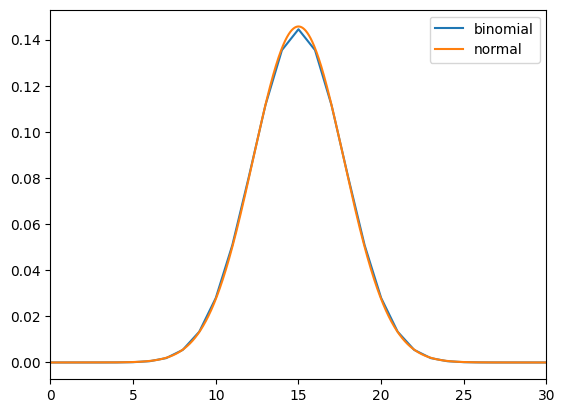

In [ ]:
# Normal distribution is an approximate for Binomial distribution, 
# yet much easier to compute than Binomial distribution

n = 30  # for n > 30 Normal distribution is good approximation
p = 0.5  # p near 0.5 gives good approximation
q = 1 - p

# Create Binomial distribution (exact)
PXbinomial = []
for k in range(n + 1):
    probX = sps.comb(n, k) * p**k * q**(n - k)
    PXbinomial.append(probX)

# Create Normal distribution (approximation)
mu = n * p
sigma = np.sqrt(n * p * q)

X = np.arange(0, n, 0.01)
PXnormal = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((X - mu)**2) / (2 * sigma**2))

# Plot
plt.plot(PXbinomial, label="binomial")
plt.plot(X, PXnormal, label="normal")
plt.legend()
plt.xlim(0, n)

### [code practice] Lecture 16. Standard Unit Normal Probability Computations

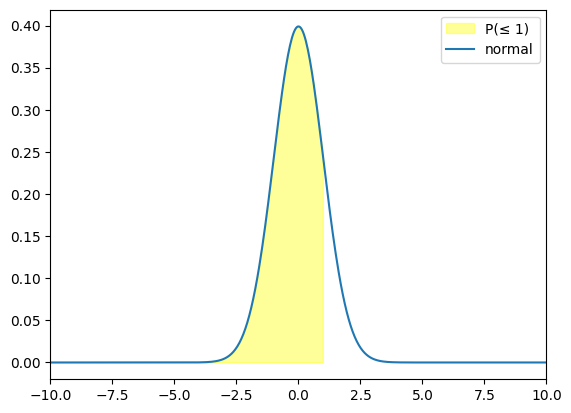

P(X ≤ 1) = 0.8413


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 0
sigma = 1

X = np.linspace(-10, 10, 500)
PXnormal = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((X - mu)**2) / (2 * sigma**2))

# Plot
mask = (X <= 1)
plt.fill_between(X, PXnormal, where=mask, alpha=0.4, color='yellow', label="P(≤ 1)")
plt.plot(X, PXnormal, label="normal")
plt.legend()
plt.xlim(-10, +10)
plt.show()

# Compute probability use cdf
probability = norm.cdf(1, mu, sigma)
print(f"P(X ≤ 1) = {probability:.4f}")

### [note] classification
Discrete distributions:
1. Bernoulli → single trial
2. Binomial (approx. Normal, Poisson)→ number of successes in n trials 
3. Geometric → trials until first success
4. Poisson → number of events in interval

Continuous distributions:
1. Exponential (give same result as Poisson)→ waiting time between events 

### [note] Lecture 20. Hazard rate and memoryless
Rationalise formula:

$P(t < T \leq t + dt) = \lambda P(T > t) \, dt$

This is $[\lambda \cdot P(T > t)]$ because $P(t < T)$ and $P(T \leq t + dt)$ are independent, i.e. their probabilities should be multiplied together to form the overall probability.